# Binary Classification Using a PyTorch Neural Network

This notebook classifies IMDB movie reviews as positive or negative using PyTorch and CUDA when available.

## Workflow

1. Load the IMDB dataset
2. Decode and display sample reviews
3. Tokenize and pad review sequences
4. Train a PyTorch text classifier
5. Report accuracy, precision, recall, F1, and confusion matrix

In [5]:
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


def tokenize(text: str):
    return re.findall(r"[a-z']+", text.lower())


print("Libraries imported successfully.")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Libraries imported successfully.


In [6]:
dataset = load_dataset("imdb")
train_texts = dataset["train"]["text"]
train_labels = np.array(dataset["train"]["label"])
test_texts = dataset["test"]["text"]
test_labels = np.array(dataset["test"]["label"])

print("Training samples:", len(train_texts))
print("Test samples:", len(test_texts))
print("Positive reviews in train set:", int(train_labels.sum()))
print("Negative reviews in train set:", int(len(train_labels) - train_labels.sum()))
print("\nSample review:")
print(train_texts[0][:1000])

counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

vocab_size = 20000
most_common = counter.most_common(vocab_size - 2)
word_to_idx = {"<PAD>": 0, "<UNK>": 1}
for word, _ in most_common:
    word_to_idx[word] = len(word_to_idx)
idx_to_word = {idx: word for word, idx in word_to_idx.items()}
max_len = 200


def encode_text(text: str):
    tokens = tokenize(text)
    indices = [word_to_idx.get(token, 1) for token in tokens[:max_len]]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    return indices


x_train = torch.tensor([encode_text(text) for text in train_texts], dtype=torch.long)
y_train = torch.tensor(train_labels, dtype=torch.float32)
x_test = torch.tensor([encode_text(text) for text in test_texts], dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.float32)

baseline_class = int(round(y_train.mean().item()))
baseline_pred = np.full(len(y_test), baseline_class)
baseline_accuracy = accuracy_score(y_test.numpy(), baseline_pred)

print("\nVocabulary size:", len(word_to_idx))
print("Sequence length:", max_len)
print("Baseline accuracy:", round(baseline_accuracy, 4))

Training samples: 25000
Test samples: 25000
Positive reviews in train set: 12500
Negative reviews in train set: 12500

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM

In [7]:
train_ds, val_ds = torch.utils.data.random_split(
    TensorDataset(x_train, y_train),
    [int(0.8 * len(x_train)), len(x_train) - int(0.8 * len(x_train))],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))

class TextCNN(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * (max_len // 2), 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = x.flatten(1)
        x = torch.relu(self.fc1(self.dropout(x)))
        return self.fc2(self.dropout(x)).squeeze(1)


model = TextCNN(len(word_to_idx)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

best_val_acc = 0.0
best_state = None
patience = 3
counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, 8):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * batch_x.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        train_correct += (preds == batch_y.long()).sum().item()
        train_total += batch_x.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            val_correct += (preds == batch_y.long()).sum().item()
            val_total += batch_x.size(0)

    train_loss /= train_total
    val_loss /= val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", round(best_val_acc, 4))

C:\Users\jenil\AppData\Local\Temp\ipykernel_22044\2976778156.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
C:\Users\jenil\AppData\Local\Temp\ipykernel_22044\2976778156.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 1: train_loss=0.6228, train_acc=0.6240, val_loss=0.4387, val_acc=0.7972
Epoch 2: train_loss=0.3748, train_acc=0.8381, val_loss=0.3649, val_acc=0.8380
Epoch 3: train_loss=0.2706, train_acc=0.8893, val_loss=0.3498, val_acc=0.8490
Epoch 4: train_loss=0.2060, train_acc=0.9223, val_loss=0.3912, val_acc=0.8582
Epoch 5: train_loss=0.1423, train_acc=0.9473, val_loss=0.3913, val_acc=0.8620
Epoch 6: train_loss=0.0981, train_acc=0.9650, val_loss=0.4741, val_acc=0.8588
Epoch 7: train_loss=0.0685, train_acc=0.9755, val_loss=0.6794, val_acc=0.8448
Best validation accuracy: 0.862


Test accuracy: 0.837
Precision: 0.8014
Recall: 0.8961
F1-score: 0.8461

Comparison (Baseline vs Model):
Accuracy: 0.5000 -> 0.8370


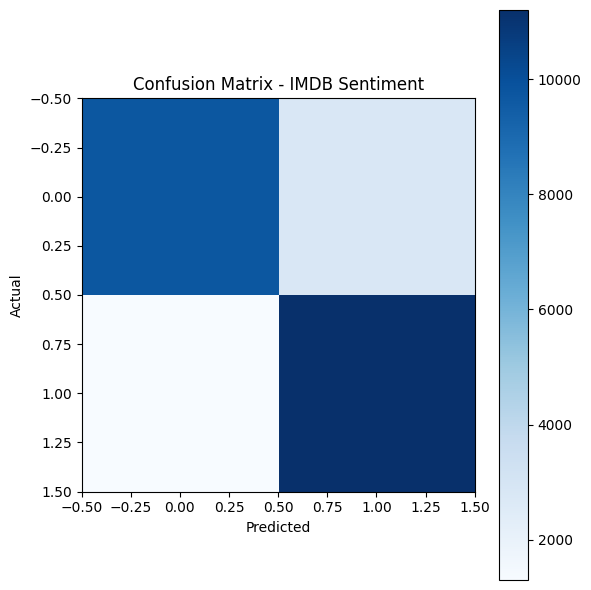

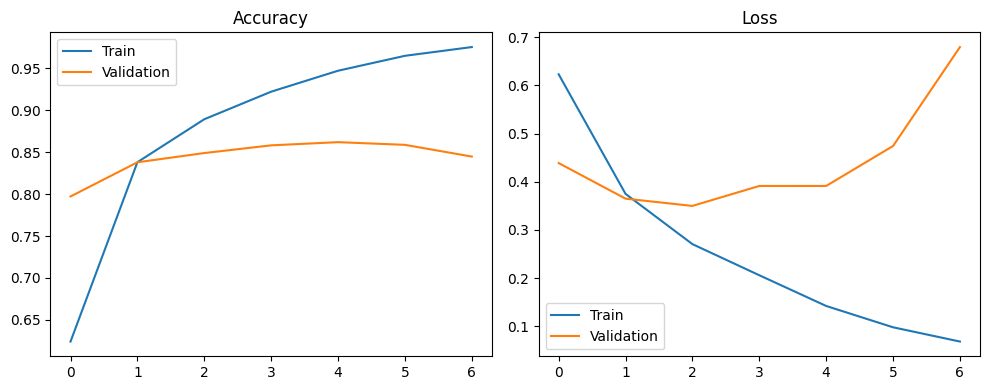

Sample predictions:
Actual: negative, Predicted: negative, Score: 0.0000
Actual: positive, Predicted: negative, Score: 0.1094
Actual: negative, Predicted: negative, Score: 0.0000
Actual: positive, Predicted: positive, Score: 1.0000
Actual: positive, Predicted: positive, Score: 0.9997


In [8]:
model.eval()
all_probs = []
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model(batch_x)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy().astype(int))

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("Test accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("\nComparison (Baseline vs Model):")
print(f"Accuracy: {baseline_accuracy:.4f} -> {accuracy:.4f}")

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - IMDB Sentiment")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(x_test), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    label = "positive" if all_preds[idx] == 1 else "negative"
    truth = "positive" if all_labels[idx] == 1 else "negative"
    print(f"Actual: {truth}, Predicted: {label}, Score: {all_probs[idx]:.4f}")